# Notebook to make Figure 10: GWTC-4.0 event vs. data-level PPCs

In [1]:
import numpy as np 
import json
from popsummary.popresult import PopulationResult

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

import sys
sys.path.append('../utils')
import plot_utils 

## Setup

Load data

**NOTE**: The data loaded to `popsummary_result` are from the GWTC-4.0 data release available on Zenodo here https://zenodo.org/records/16911563; these are excluded from this repository.

In [2]:
# Population traces
popsummary_result = PopulationResult(
    fname='/home/simona.miller/o4a-astro/data_release/BBHSpin_MagTruncnormIidTiltIsotropicTruncnormNid.h5'
)

# Predicted vs. Observed PPC traces 
eventlevel_predobs = np.load('../data/GWTC4_PPC_traces_event_level.npz', allow_pickle=True)['arr_0'].item()
datalevel_predobs = np.load('../data/GWTC4_PPC_traces_data_level.npz', allow_pickle=True)['arr_0'].item()

Get population traces from `popsummary` file

In [3]:
chi_grid, chi_rates = popsummary_result.get_rates_on_grids('a')
cost_grid, cost_rates = popsummary_result.get_rates_on_grids('cos_tilt')

Get fraction under predicted for $\chi$ and $\cos\theta$

In [4]:
parameters = ['a', 'cos_tilt']

## event level
frac_underpred_event = plot_utils.fraction_underpredicted(eventlevel_predobs, parameters, ncut=2)[1]

## data level
frac_underpred_data = plot_utils.fraction_underpredicted(datalevel_predobs, parameters, ncut=2)[1]

Plotting labels, aesthetics, etc.

In [5]:
bounds = {'a':[0,1],'cos_tilt':[-1,1]}
hist_kws =  dict(histtype='step', ls=':', color='k', bins=20, density=True)

## Make figure

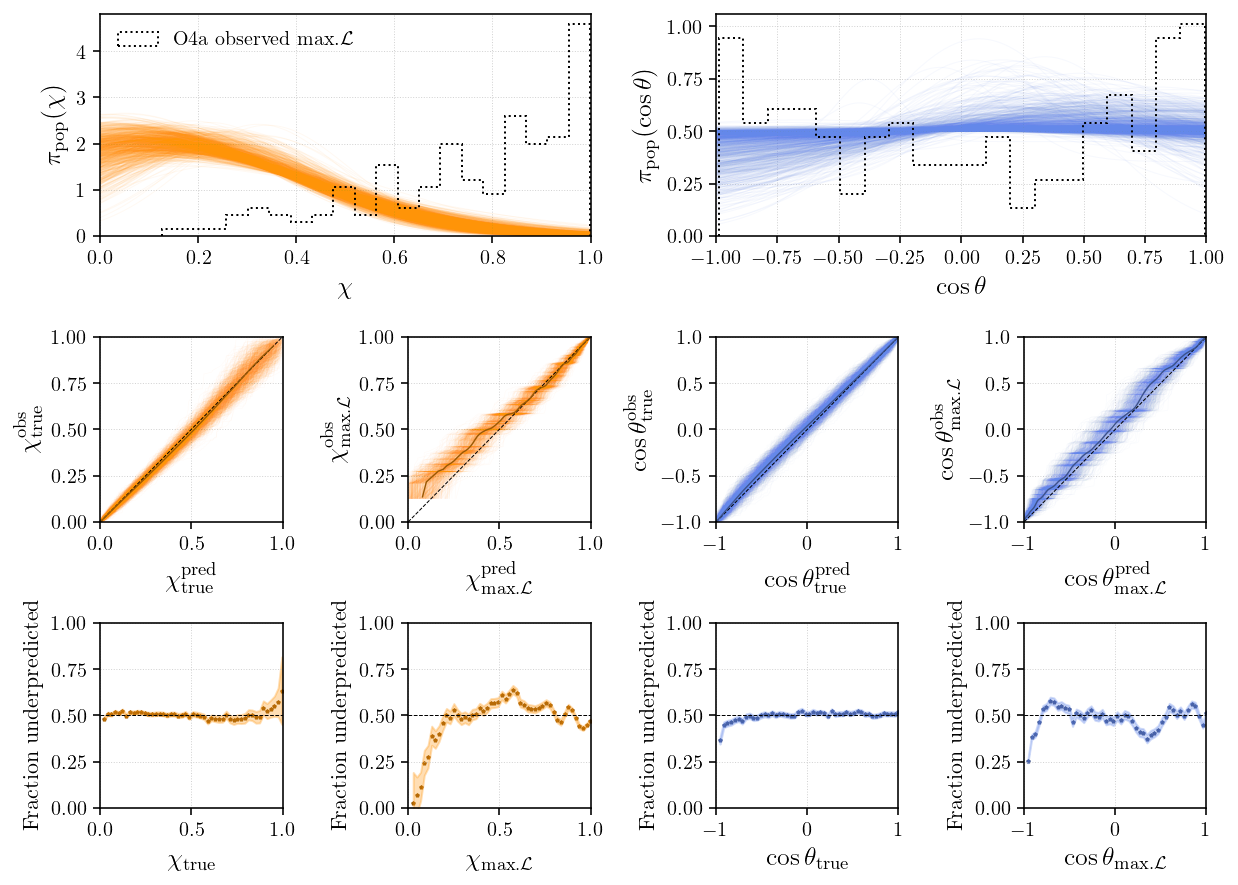

In [6]:
fig = plt.figure(figsize=(13/1.5,10/1.6))

# Set up axes: add subplots to specific locations and spans in the grid
gs = GridSpec(3, 4, width_ratios=[1, 1, 1, 1], height_ratios=[1.2, 1, 1])
ax_chi_top = fig.add_subplot(gs[0, 0:2])     
ax_tilt_top = fig.add_subplot(gs[0, 2:])
axes_event_chi = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[2, 0])]
axes_data_chi = [fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[2, 1])]
axes_event_tilt = [fig.add_subplot(gs[1, 2]), fig.add_subplot(gs[2, 2])]
axes_data_tilt = [fig.add_subplot(gs[1, 3]), fig.add_subplot(gs[2, 3])]

# Population distribution
ax_chi_top.plot(chi_grid.flatten(), chi_rates[:1000].T, color=plot_utils.GWTC4_chi_color, lw=0.5, alpha=0.05)
ax_chi_top.hist(datalevel_predobs['observed']['a'][0], **hist_kws, label=r'O4a observed $\mathrm{max}.\mathcal{L}$')
ax_chi_top.set_xlim(0,1)
ax_chi_top.set_ylim(0,)
ax_chi_top.set_xlabel(r'$\chi$', fontsize=13)
ax_chi_top.set_ylabel(r'$\pi_{\rm pop}(\chi)$', fontsize=13)
ax_chi_top.grid()
ax_chi_top.legend(frameon=False)

ax_tilt_top.plot(cost_grid.flatten(), cost_rates[:1000].T, color=plot_utils.GWTC4_tilt_color, lw=0.5, alpha=0.05)
ax_tilt_top.hist(datalevel_predobs['observed']['cos_tilt'][0], **hist_kws, label=r'O4a observed $\mathrm{max}.\mathcal{L}$')
ax_tilt_top.set_xlim(-1,1)
ax_tilt_top.set_ylim(0,)
ax_tilt_top.set_xlabel(r'$\cos\theta$', fontsize=13)
ax_tilt_top.set_ylabel(r'$\pi_{\rm pop}(\cos\theta)$', fontsize=13)
ax_tilt_top.grid()

# Event vs. data-level PPCs: traces and fraction underpredicted
plot_utils.traces_and_underpred_plot(
    axes_event_chi, eventlevel_predobs, frac_underpred_event, 'a', color=plot_utils.GWTC4_chi_color, lbl=plot_utils.GWTC4_labels_data_vs_event['a']['event']
)
plot_utils.traces_and_underpred_plot(
    axes_data_chi, datalevel_predobs, frac_underpred_data, 'a', color=plot_utils.GWTC4_chi_color, lbl=plot_utils.GWTC4_labels_data_vs_event['a']['data']
)
plot_utils.traces_and_underpred_plot(
    axes_event_tilt, eventlevel_predobs, frac_underpred_event, 'cos_tilt', color=plot_utils.GWTC4_tilt_color, lbl=plot_utils.GWTC4_labels_data_vs_event['tilt']['event']
)
plot_utils.traces_and_underpred_plot(
    axes_data_tilt, datalevel_predobs, frac_underpred_data, 'cos_tilt', color=plot_utils.GWTC4_tilt_color, lbl=plot_utils.GWTC4_labels_data_vs_event['tilt']['data']
)
   
plt.tight_layout()

plt.savefig('figure_10.png', dpi=300, bbox_inches='tight')
plt.show()